# **실습 2. MLP Regression** 

-  Kaggle 'Smartphone_Usage_And_Addiction_Analysis' 데이터를 사용한 실습
-  이진 분류 문제 (binary classification problem) - Addicted or Not Addicted 

Note 1: Kaggle에 공개된 내용을 강의에 맞도록 정리하고 한글화하엿음

Note 2: 앞서 Logistic Regression 과 공평한 비교를 위하여 입력 데이터를 3개로 제한 하였음. 

# 1. Data Loading

In [2]:
import numpy as np
import pandas as pd

df = pd.read_csv(r"Smartphone_Usage_And_Addiction_Analysis_7500_Rows.csv")
df.head()

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

### 데이터 특성
- 7500 rows and 16 columns  
- Among the columns:
    6 are of type `float`
    4 are of type `int`
    6 are of type `object
- Only *addiction_level* column has missing values. 
`

# 2. Data Preprocessing

## Train, (Validation), Test 용으로 데이터를 나눔 

In [25]:
from sklearn.model_selection import train_test_split

#x = df.drop("addicted_label", axis=1)
x = df[['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time']]
y = df["addicted_label"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_test, y_test, test_size=0.5, random_state=42)
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(6000, 3) (6000,)
(750, 3) (750,)
(750, 3) (750,)


### Normalizing the data (매우중요함) 
- 입력에 따른 데이터의 크기를 일정하게 해서, 특정 입력에 필요이상 의존되지 않도록 함
- 예, meter 로 표시하는가 cm 로하는가에 따라 수치는 커지나 실제 값은 동일

In [26]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)
x_test = scaler.transform(x_test)

print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(6000, 3) (6000,)
(750, 3) (750,)
(750, 3) (750,)


## dataset 과 DataLoader

- 다양한 데티터 입력을 지원학 위하여 Dataset 기본 클레스를 제공함
- 고속 데이터 로딩 처리를 위한 Dataloader는 라이브러리 것을 사용 

In [28]:
from torch.utils.data import Dataset, DataLoader

class dataset(Dataset):

    def __init__(self, x, y):
        self.x = torch.tensor(x.values, dtype=torch.float32).to(device)
        self.y = torch.tensor(y.values, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.x)

    def __getitem__(self, index):
        return self.x[index], self.y[index]

In [30]:
train_data = dataset(pd.DataFrame(x_train), y_train)
val_data = dataset(pd.DataFrame(x_val), y_val)
test_data = dataset(pd.DataFrame(x_test), y_test)

train_dataloader = DataLoader(train_data, batch_size=16, shuffle=True)  # 보통 순서를 뒤섞음
val_dataloader = DataLoader(val_data, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_data, batch_size=16, shuffle=False)

# 3. 모델 정의 

3 => 32 => 16 => 1 의 구조를 정의함

In [31]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [32]:
import torch.nn as nn

class Model(nn.Module):

    def __init__(self):
        super(Model, self).__init__()
        
        self.network = nn.Sequential(
            nn.Linear(x.shape[1], 32),
            nn.ReLU(),
        
            nn.Linear(32, 16),
            nn.ReLU(),

            nn.Linear(16, 1),
            nn.Sigmoid()
            )

    def forward(self, x):
        return self.network(x)

model = Model().to(device)

In [33]:
from torchsummary import summary

summary(model, (x.shape[1], ))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 32]             128
              ReLU-2                   [-1, 32]               0
            Linear-3                   [-1, 16]             528
              ReLU-4                   [-1, 16]               0
            Linear-5                    [-1, 1]              17
           Sigmoid-6                    [-1, 1]               0
Total params: 673
Trainable params: 673
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


In [34]:
from torch.optim import Adam

criterion = nn.BCELoss()  # BCE is used as the loss function to measure how well the model predicts probabilities for binary classification.
optimizer = Adam(model.parameters(), lr=0.0001)  # Adam is an optimizer that adjusts the model's weights during training to minimize the loss efficiently.

## 4. 학습 

In [35]:
NUM_EPOCH = 100
total_train_loss = []
total_train_acc = []
total_val_loss = []
total_val_acc = []

for epoch in range(NUM_EPOCH):
    train_loss = 0
    train_acc = 0
    val_loss = 0
    val_acc = 0

    for data in train_dataloader:
        inputs, labels = data

        pred = model(inputs).squeeze(1)
        barch_loss = criterion(pred, labels)
        train_loss += barch_loss.item()

        acc = (pred.round() == labels).sum().item()
        train_acc += acc

        optimizer.zero_grad()
        barch_loss.backward()
        optimizer.step()

    with torch.no_grad():
        for data in val_dataloader:
            inputs, labels = data

            pred = model(inputs).squeeze(1)
            barch_loss = criterion(pred, labels)
            val_loss += barch_loss.item()

            acc = (pred.round() == labels).sum().item()
            val_acc += acc

    total_train_loss.append(round(train_loss / len(train_dataloader), 3))
    total_val_loss.append(round(val_loss / len(val_dataloader), 3))
    total_train_acc.append(round(train_acc / train_data.__len__() * 100, 2))
    total_val_acc.append(round(val_acc / val_data.__len__() * 100, 2))

    print(f"Epoch {epoch+1} Train Loss: {total_train_loss[-1]} Train Accuracy: {total_train_acc[-1]} Validation Loss: {total_val_loss[-1]} Validation Accuracy: {total_val_acc[-1]}")

Epoch 1 Train Loss: 0.638 Train Accuracy: 74.0 Validation Loss: 0.563 Validation Accuracy: 87.47
Epoch 2 Train Loss: 0.488 Train Accuracy: 88.27 Validation Loss: 0.418 Validation Accuracy: 89.73
Epoch 3 Train Loss: 0.362 Train Accuracy: 90.02 Validation Loss: 0.316 Validation Accuracy: 91.33
Epoch 4 Train Loss: 0.281 Train Accuracy: 90.65 Validation Loss: 0.255 Validation Accuracy: 91.47
Epoch 5 Train Loss: 0.235 Train Accuracy: 90.82 Validation Loss: 0.221 Validation Accuracy: 91.6
Epoch 6 Train Loss: 0.209 Train Accuracy: 91.25 Validation Loss: 0.203 Validation Accuracy: 91.87
Epoch 7 Train Loss: 0.195 Train Accuracy: 91.5 Validation Loss: 0.192 Validation Accuracy: 91.73
Epoch 8 Train Loss: 0.185 Train Accuracy: 91.55 Validation Loss: 0.186 Validation Accuracy: 91.47
Epoch 9 Train Loss: 0.179 Train Accuracy: 91.6 Validation Loss: 0.181 Validation Accuracy: 91.33
Epoch 10 Train Loss: 0.174 Train Accuracy: 91.77 Validation Loss: 0.178 Validation Accuracy: 91.33
Epoch 11 Train Loss: 0.

# 5. 평가 

In [37]:
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

with torch.no_grad():
    total_test_loss = 0
    total_test_acc = 0

    for data in test_dataloader:
        inputs, labels = data

        pred = model(inputs).squeeze(1)
        barch_loss_test = criterion(pred, labels).item()
        total_test_loss += barch_loss_test

        acc = (pred.round() == labels).sum().item()
        total_test_acc += acc

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(pred.round().cpu().numpy())

print(f"Accuracy: {round(total_test_acc / test_data.__len__() * 100, 2)}%")
print("\nClassification Report:\n\n", classification_report(y_true, y_pred))

Accuracy: 92.13%

Classification Report:

               precision    recall  f1-score   support

         0.0       0.85      0.91      0.88       233
         1.0       0.96      0.93      0.94       517

    accuracy                           0.92       750
   macro avg       0.90      0.92      0.91       750
weighted avg       0.92      0.92      0.92       750



Text(0.5, 1.0, 'Confusion Matrix')

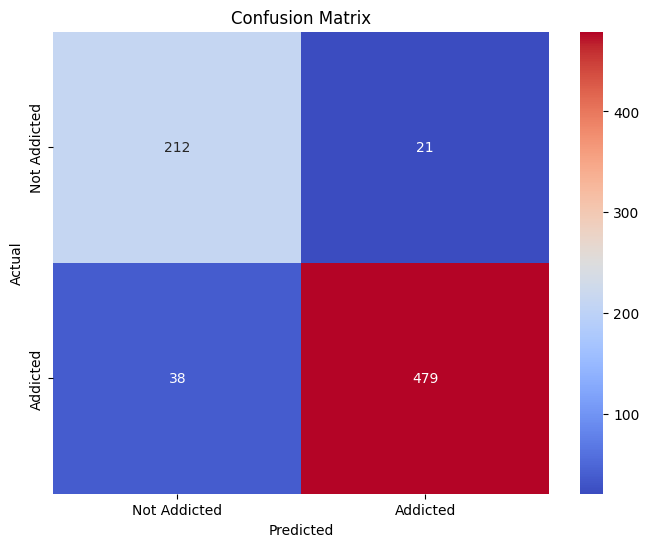

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
con_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))
ax = sns.heatmap(con_matrix, annot=True, fmt="g", cmap="coolwarm")

ax.set_xticklabels(["Not Addicted", "Addicted"], ha="center")
ax.set_yticklabels(["Not Addicted", "Addicted"], va="center")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

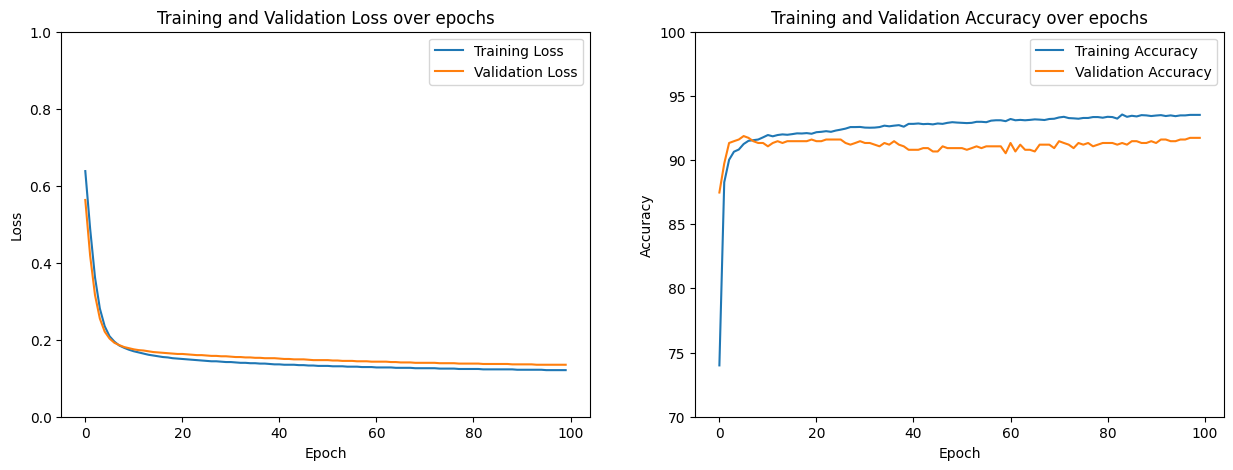

In [41]:
fig, axis = plt.subplots(1, 2, figsize=(15,5))

axis[0].plot(total_train_loss, label="Training Loss")
axis[0].plot(total_val_loss, label="Validation Loss")
axis[0].set_title("Training and Validation Loss over epochs")
axis[0].set_xlabel("Epoch")
axis[0].set_ylabel("Loss")
axis[0].set_ylim([0,1])
axis[0].legend()

axis[1].plot(total_train_acc, label="Training Accuracy")
axis[1].plot(total_val_acc, label="Validation Accuracy")
axis[1].set_title("Training and Validation Accuracy over epochs")
axis[1].set_xlabel("Epoch")
axis[1].set_ylabel("Accuracy")
axis[1].set_ylim([70,100])
axis[1].legend()

# 결론 

- Logistic Regression 은 MLP의 특별한 경우로 생각할 수 있음
     - 출력 노드 1 neuron,  중간 레이어 없음, Activation은 Sigmoid 함수
 
- 이 데이터셋의 경우 ANN이 성능이 Logistic Regression에 비하여 월등히 높다고 볼 수는 없음 (물론, 이 정도면 논문에서는 높다고 주장하고 출판이됨)
     - 그 이유는 입력변수들간의 상호작용이 많지 않기 때문이라고 보임.
     - 즉, 어떤 두개, 세꼐의 요소가 복합적인 패턴을 만족하였을 때 중독에 영향을 준것이 아니라, 각각이 일정한 비율로 영향을 주었기 때문이라고 해석됨
     - 따라서 Logistic regression으로 충분히 원하는 결과를 얻는 경우, 궂이 복잡한 NN을 이용하는 것은 실제적으로 의미가 없다는 판단.
       